In [1]:
%load_ext autoreload
%autoreload 2

import glob, h5py, math, time, os, json
from scipy.stats import norm, expon, chi2, uniform, chisquare, gamma
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import torch

import sys  
from tqdm import tqdm

sys.path.append("../../")
from utils.plotting import make_corner
from utils.mahaTools import mahalanobis_dist
from utils.ANALYSISutils import median_score

/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


100%|██████████| 500/500 [00:04<00:00, 121.77it/s]


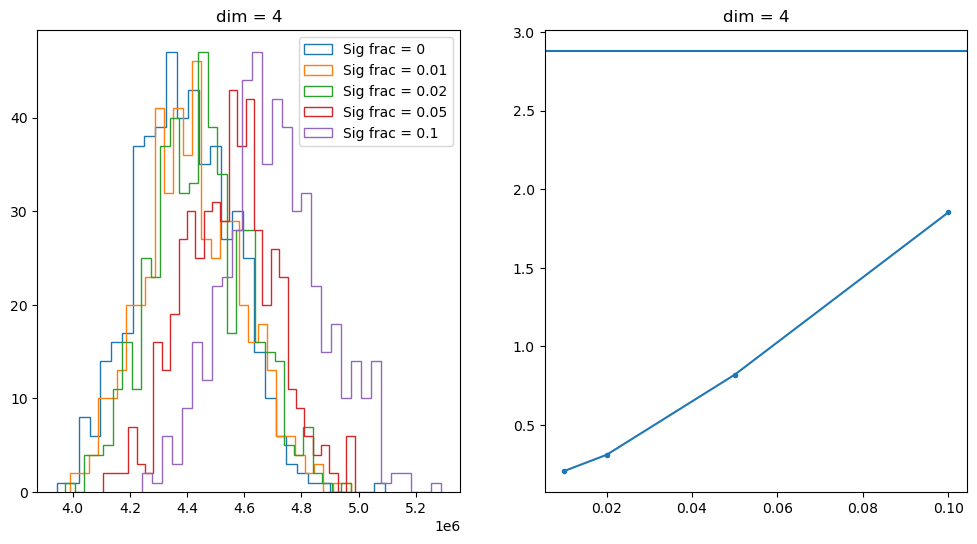

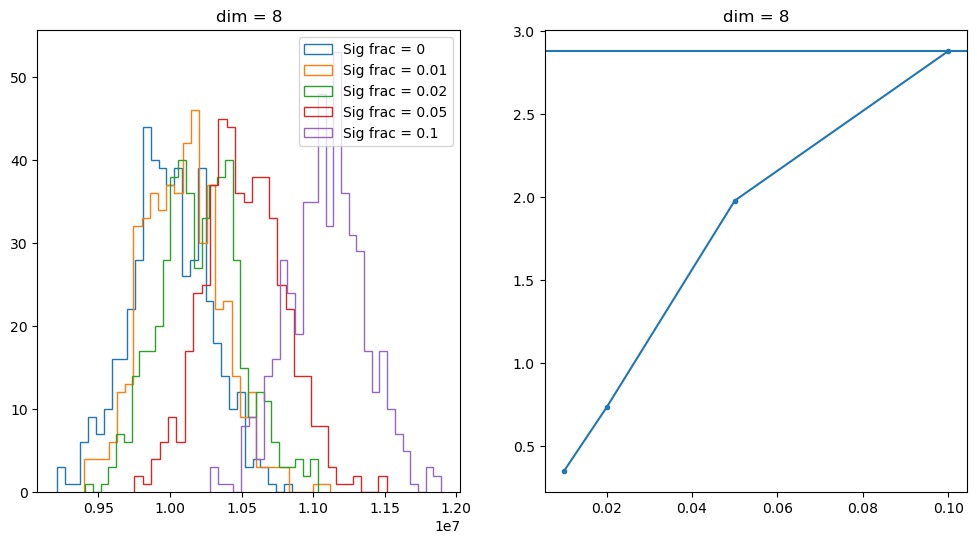

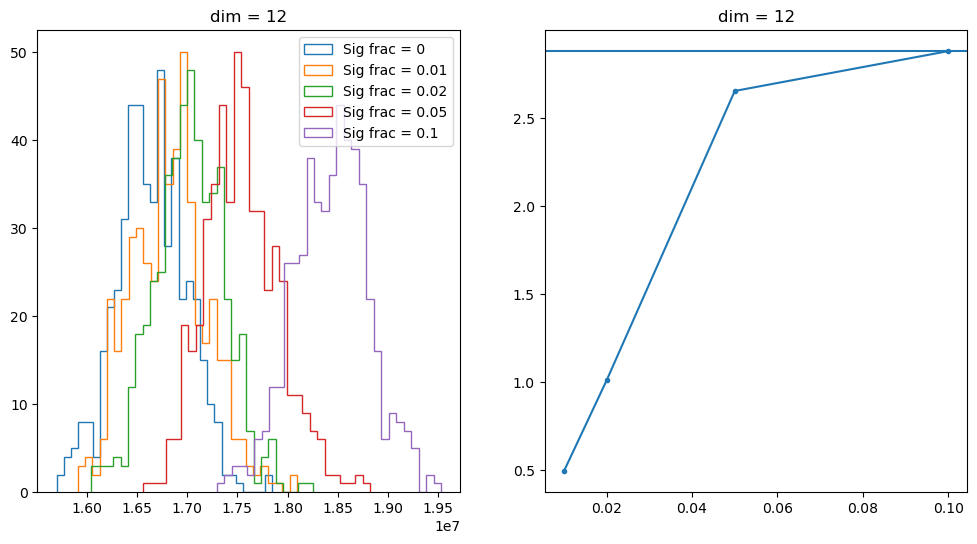

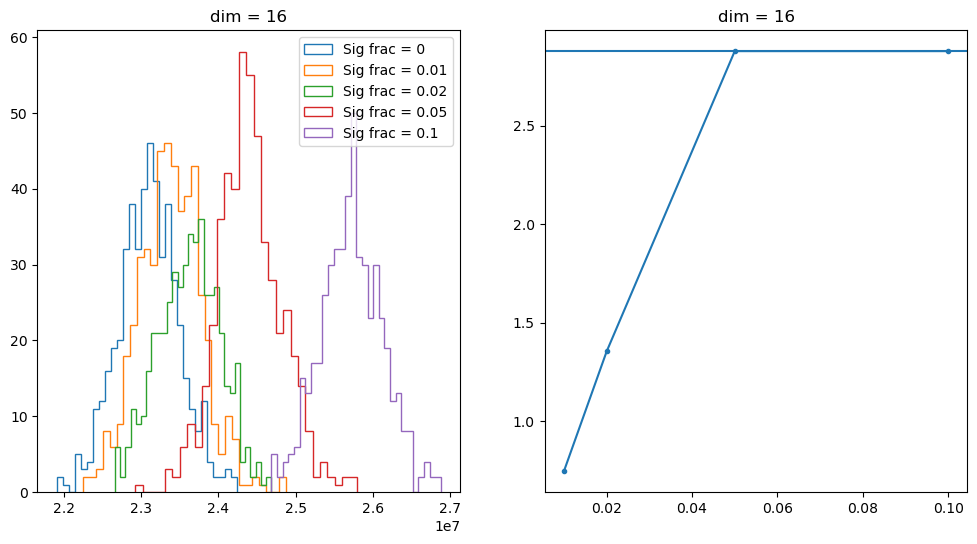

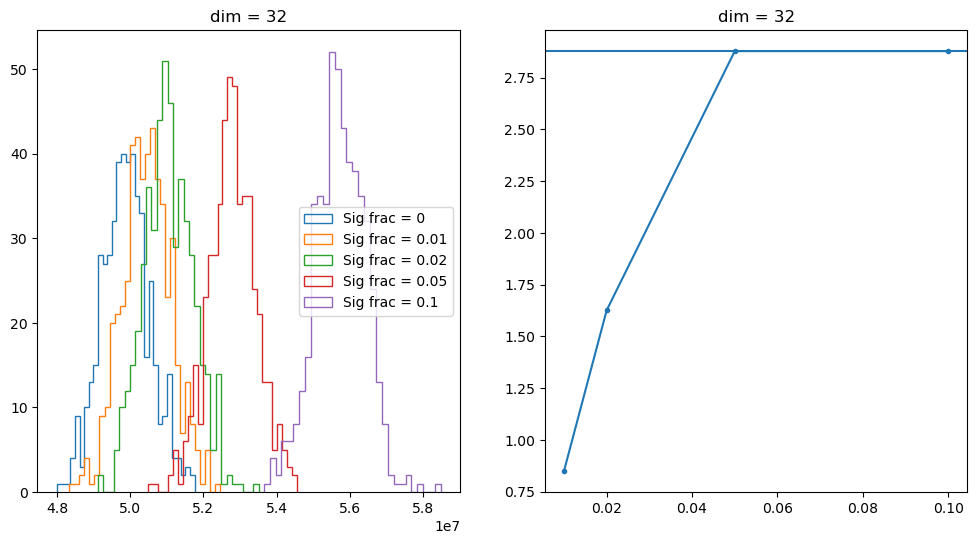

In [2]:
for dim in [4,8,12,16,32]:
    dim_label = f"_dim{dim}" if dim != 4 else ""

    base = f"/n/home11/sambt/phlab-neurips25/experiments/cifar10/embeddings_noShift_spaceWithClassifier/cifar_excludeClass1{dim_label}/"
    f_ref = f"{base}/cifar10_test.npz"
    f_bkg = f"{base}/cifar5m_N100000.npz"

    ref_data = np.load(f_ref)
    bkg_data = np.load(f_bkg)
    anom_label = 1

    ref_mask = ref_data['labels'] != anom_label
    bkg_mask = bkg_data['labels'] != anom_label

    ref = ref_data['data'][ref_mask]
    ref_labels = ref_data['labels'][ref_mask]
    bkg = bkg_data['data'][bkg_mask]
    bkg_labels = bkg_data['labels'][bkg_mask]
    anom = bkg_data['data'][~bkg_mask]
    anom_labels = bkg_data['labels'][~bkg_mask]

    nbkg = 1800
    sig_fracs = [0,0.01,0.02,0.05,0.1]
    Ntoys = 500

    all_ts = []
    for fsig in sig_fracs:
        nsig = int(fsig * nbkg)
        ts = []
        for i in tqdm(range(Ntoys)):
            bkg_inj_idx = np.random.choice(np.arange(len(bkg)),size=nbkg,replace=False)
            sig_inj_idx = np.random.choice(np.arange(len(anom)),size=nsig,replace=False)
            data = np.concatenate([bkg[bkg_inj_idx],anom[sig_inj_idx]])
            t,M = mahalanobis_dist(torch.tensor(data),torch.tensor(ref),torch.tensor(ref_labels),plot=False)
            ts.append(t.item())
        all_ts.append(ts)
    all_ts = [np.array(a) for a in all_ts]

    fig,axes = plt.subplots(1,2,figsize=(12,6))
    plt.sca(axes[0])
    for i,ts in enumerate(all_ts):
        plt.hist(ts,bins=30,histtype='step',label=f"Sig frac = {sig_fracs[i]}")
    plt.legend()
    plt.title(f"dim = {dim}")

    from scipy.stats import norm
    zscores = []
    tref = all_ts[0]
    for tobs in all_ts[1:]:
        t_empirical = np.sum(1.*(tref>np.mean(tobs)))*1./tref.shape[0]
        if t_empirical==0:
            empirical_lim='>'
            t_empirical = 1./tref.shape[0]
        z = norm.ppf(1-t_empirical)
        zscores.append(z)
    plt.sca(axes[1])
    plt.plot(sig_fracs[1:],zscores,marker='.')
    plt.axhline(norm.ppf(1-1/len(tref)))
    plt.title(f"dim = {dim}")

    np.savez(f"cifar10_maha_empiricalZscore{dim_label}.npz",zscores=zscores,fracs=sig_fracs[1:])